# Import Required Libraries

In [8]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import os

parent_dir = os.path.abspath(os.path.join('..', '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Load JSONL Data

In [9]:
log_file_path = os.path.join(parent_dir, 'logs', 'LogTesting_Aruco_log_1756982142.jsonl')
with open(log_file_path, 'r') as f:
    lines = f.readlines()
data = [json.loads(line) for line in lines]

# Process Data for Plotting

In [10]:
distances = defaultdict(lambda: defaultdict(list))
for entry in data:
    if entry['tag'] == 'aruco' and entry['data']:
        cambot = entry['cambot_id']
        time = entry['time']
        for aruco_id, info in entry['data'].items():
            distances[cambot][aruco_id].append((time, info['distance']))

all_times = [time for cambot in distances for aruco in distances[cambot] for time, _ in distances[cambot][aruco]]
global_min_time = min(all_times) if all_times else 0
global_max_time = max(all_times) if all_times else 1

all_dists = [dist for cambot in distances for aruco in distances[cambot] for _, dist in distances[cambot][aruco]]
global_min_dist = min(all_dists) if all_dists else 0
global_max_dist = max(all_dists) if all_dists else 12

# Plot Distance Over Time

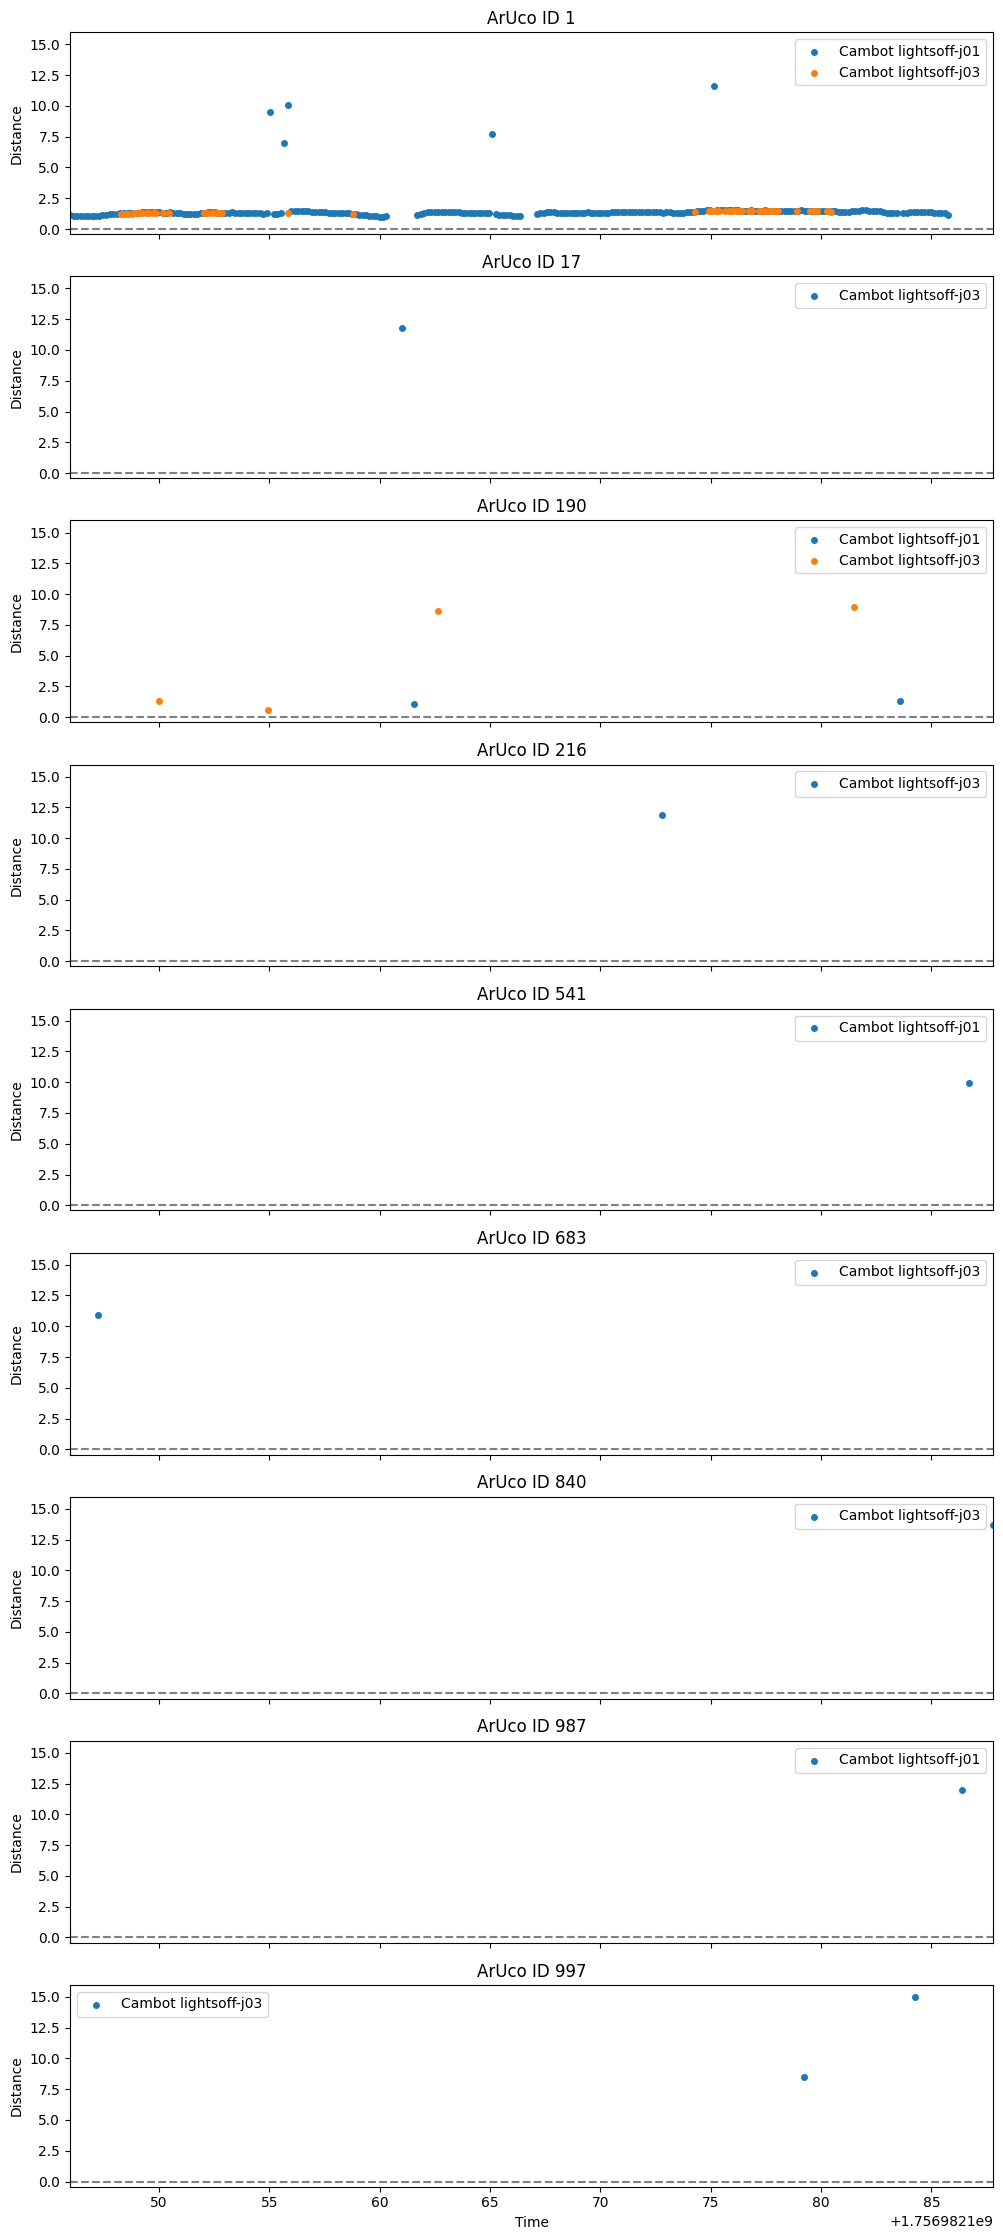

In [11]:

all_aruco_ids = set()
for cambot in distances:
    for aruco_id in distances[cambot]:
        all_aruco_ids.add(aruco_id)

fig, axes = plt.subplots(len(all_aruco_ids), 1, figsize=(10, 2.5 * len(all_aruco_ids)), sharex=True)
if len(all_aruco_ids) == 1:
    axes = [axes]

for i, aruco_id in enumerate(sorted(all_aruco_ids)):
    ax = axes[i]
    for cambot in distances:
        if aruco_id in distances[cambot]:
            times, dists = zip(*distances[cambot][aruco_id])
            ax.scatter(times, dists, label=f'Cambot {cambot}', marker='o', s=16)
    ax.set_title(f'ArUco ID {aruco_id}')
    ax.set_ylabel('Distance')
    ax.legend()
    ax.set_ylim(min(0, global_min_dist - 1), max(12, global_max_dist + 1))
    ax.axhline(y=0, color='gray', linestyle='--')

plt.xlabel('Time')
plt.xlim(global_min_time, global_max_time)
plt.tight_layout()
plt.show()

# Load Holes Data

In [12]:
log_file_path_holes = os.path.join(parent_dir, 'logs', 'LogTesting_Holes_log_1756982213.jsonl')
with open(log_file_path_holes, 'r') as f:
    lines_holes = f.readlines()
data_holes = [json.loads(line) for line in lines_holes]

# Process Holes Data

In [13]:
import math

diagonals = defaultdict(lambda: defaultdict(list))
for entry in data_holes:
    if entry['tag'] == 'holes' and entry['data']:
        cambot = entry['cambot_id']
        time = entry['time']
        for hole_id, info in entry['data'].items():
            bbox = info['bbox']
            x_min, y_min, x_max, y_max = bbox
            diag = math.sqrt((x_max - x_min)**2 + (y_max - y_min)**2)
            diagonals[cambot][hole_id].append((time, diag))

all_times_holes = [time for cambot in diagonals for hole in diagonals[cambot] for time, _ in diagonals[cambot][hole]]
global_min_time_holes = min(all_times_holes) if all_times_holes else 0
global_max_time_holes = max(all_times_holes) if all_times_holes else 1

all_diags = [diag for cambot in diagonals for hole in diagonals[cambot] for _, diag in diagonals[cambot][hole]]
global_min_diag = min(all_diags) if all_diags else 0
global_max_diag = max(all_diags) if all_diags else 100

# Plot Holes Diagonals

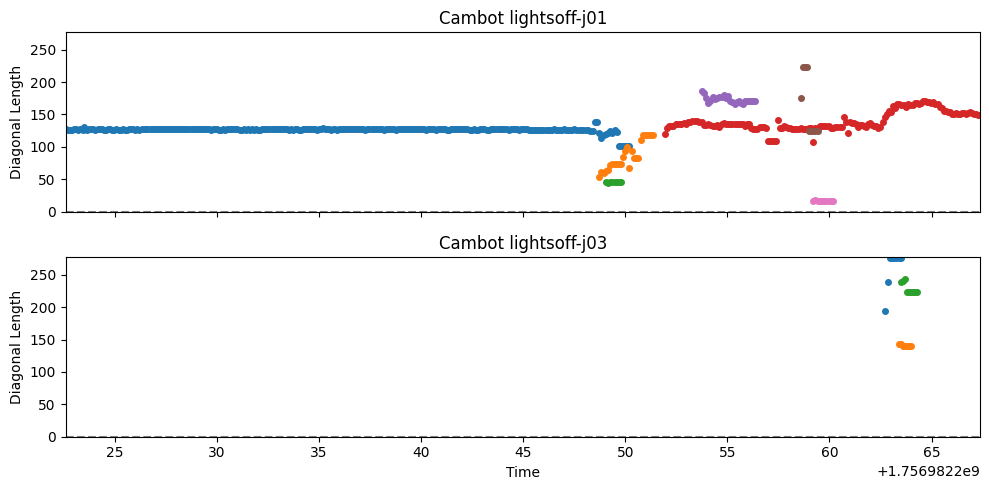

In [14]:
all_cambots = set(diagonals.keys())
fig, axes = plt.subplots(len(all_cambots), 1, figsize=(10, 2.5 * len(all_cambots)), sharex=True)
if len(all_cambots) == 1:
    axes = [axes]

for i, cambot in enumerate(sorted(all_cambots)):
    ax = axes[i]
    for hole_id in diagonals[cambot]:
        times, diags = zip(*diagonals[cambot][hole_id])
        ax.scatter(times, diags, label=f'Hole {hole_id}', marker='o', s=16)
    ax.set_title(f'Cambot {cambot}')
    ax.set_ylabel('Diagonal Length')
    ax.set_ylim(min(0, global_min_diag - 1), max(100, global_max_diag + 1))
    ax.axhline(y=0, color='gray', linestyle='--')

plt.xlabel('Time')
plt.xlim(global_min_time_holes, global_max_time_holes)
plt.tight_layout()
plt.show()